In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("mysql+mysqlconnector://root@localhost/climate_watch")
df_test = pd.read_sql("SELECT * FROM world_population_growth LIMIT 5", engine)
print(df_test)

   Year  population  yearly_growth_pct  annual_increase  density_km2
0  1951           2               1.75               43         17.0
1  1952           2               1.85               47         17.0
2  1953           2               1.93               50         18.0
3  1954           2               1.96               51         18.0
4  1955           2               2.01               54         18.0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

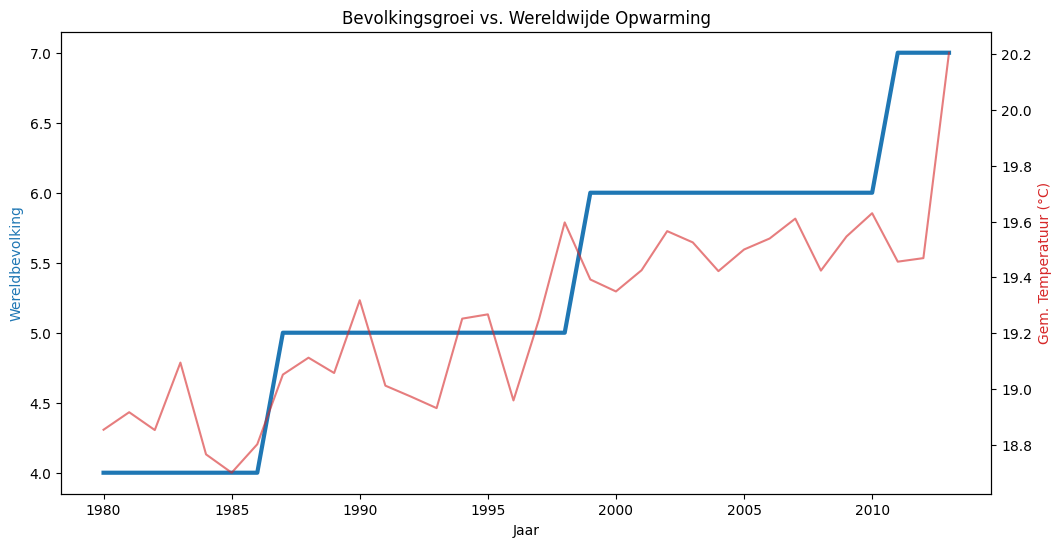

In [4]:
query_comb = """
SELECT 
    p.year, 
    p.population, 
    AVG(t.AverageTemperature) as global_temp
FROM 
    world_population_growth p
JOIN 
    cleaned_global_temp_country t ON p.year = YEAR(t.dt)
GROUP BY 
    p.year
"""
df_comb = pd.read_sql(query_comb, engine)

# Plot maken met twee assen
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bevolking op de eerste as
ax1.set_xlabel('Jaar')
ax1.set_ylabel('Wereldbevolking', color='tab:blue')
ax1.plot(df_comb['year'], df_comb['population'], color='tab:blue', linewidth=3, label='Bevolking')

# Temperatuur op de tweede as (rechts)
ax2 = ax1.twinx()
ax2.set_ylabel('Gem. Temperatuur (°C)', color='tab:red')
ax2.plot(df_comb['year'], df_comb['global_temp'], color='tab:red', alpha=0.6, label='Temperatuur')

plt.title('Bevolkingsgroei vs. Wereldwijde Opwarming')
plt.show()